<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 4</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Mohammad Hossein Mazaheri <br>
        <b>🆔 Student ID:</b> 810102585 <br><br>
        <h5 style="color: #1a365d;"> TASK 2 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 4 - Task 2. It focuses on visual recognition using a <b>Convolutional Neural Network (CNN)</b> on a dataset of fruits and vegetables. Beyond accuracy, this notebook emphasizes rigorous mathematical foundations, robustness testing (color vs. shape), and explainability using Grad-CAM.
</div>

##

## Table of Contents
1. [Statistical EDA & Preprocessing](#exploration)
2. [Model Architecture & Training](#modeling)
3. [Robustness Analysis](#robustness)
4. [Explainability with Grad-CAM](#explainability)

<a id="exploration"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Statistical EDA & Preprocessing</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We analyze the RGB distribution and Euclidean distance between 10 target classes to identify color similarities. We then implement a global Z-score normalizer fitted solely on the training data, and construct an image augmentation pipeline to improve generalization.
</div>

##

In [1]:
import sys
import subprocess

packages = {
    'torch': 'torch',
    'torchvision': 'torchvision',
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'cv2': 'opencv-python',
    'scipy': 'scipy',
    'sklearn': 'scikit-learn',
}

print("--- Checking Requirements ---")
for import_name, pip_name in packages.items():
    try:
        __import__(import_name)
        print(f"✅ {pip_name} is already installed.")
    except ImportError:
        print(f"⏳ Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        print(f"✅ {pip_name} installed successfully.")
        
print("--- All requirements are met! ---")

--- Checking Requirements ---
✅ torch is already installed.
✅ torchvision is already installed.
✅ numpy is already installed.
✅ pandas is already installed.
✅ matplotlib is already installed.
✅ seaborn is already installed.
✅ opencv-python is already installed.
✅ scipy is already installed.
⏳ Installing scikit-learn...
✅ scikit-learn installed successfully.
--- All requirements are met! ---


In [2]:
import sys
# !"{sys.executable}" -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 --force-reinstall

# 1. Dataset Description & Configuration

## 1.1. Strategic Class Selection
For this assignment, exactly 10 strategic classes are selected from the dataset following the recommended baseline. This configuration creates a highly challenging environment for the network by establishing explicit "color traps"—pairs of classes with extreme color profile overlaps but completely distinct geometries, surface textures, and structural boundaries.

The selected classes and their strategic roles include:
* **Red Group (Trap Pair 1):** `Apple` vs. `Tomato` (High color profile similarity; distinct structural textures and stem morphologies).
* **Yellow Group (Trap Pair 2):** `Banana` vs. `Lemon` (Identical primary color space; extreme difference in shape convexity and elongation).
* **Orange Group (Trap Pair 3):** `Orange` vs. `Carrot` (High color similarity; spherical organic form vs. elongated, tapered root geometry).
* **Green/Varied Group:** `Bell Pepper`, `Grapes`, `Kiwi`, and `Pear` (Provides diverse intra-class variance in scale, clustering patterns, and texture profiles).

By forcing these semantic overlaps, the model cannot achieve optimal performance using simple low-level RGB color statistics. It is systematically driven to learn high-level spatial abstractions and geometric features.

## 1.2. Preprocessing & Standarization Setup
To adhere strictly to the guidelines:
1. All incoming images are dynamically resized to **128x128 pixels** to normalize dimensional variations.
2. Every sample is verified and loaded as a standard **RGB** three-channel tensor.
3. The original dataset partitions (**Train, Validation, and Test**) are strictly preserved without cross-contamination.

=== Exact Sample Count Per Split For Each Class ===
Split        train  validation  test
Class                               
apple           68          10    10
banana          75           9     9
bell pepper     90           9    10
carrot          82           9    10
grapes         100           9    10
kiwi            88          10    10
lemon           82          10    10
orange          69           9    10
pear            89          10    10
tomato          92          10    10


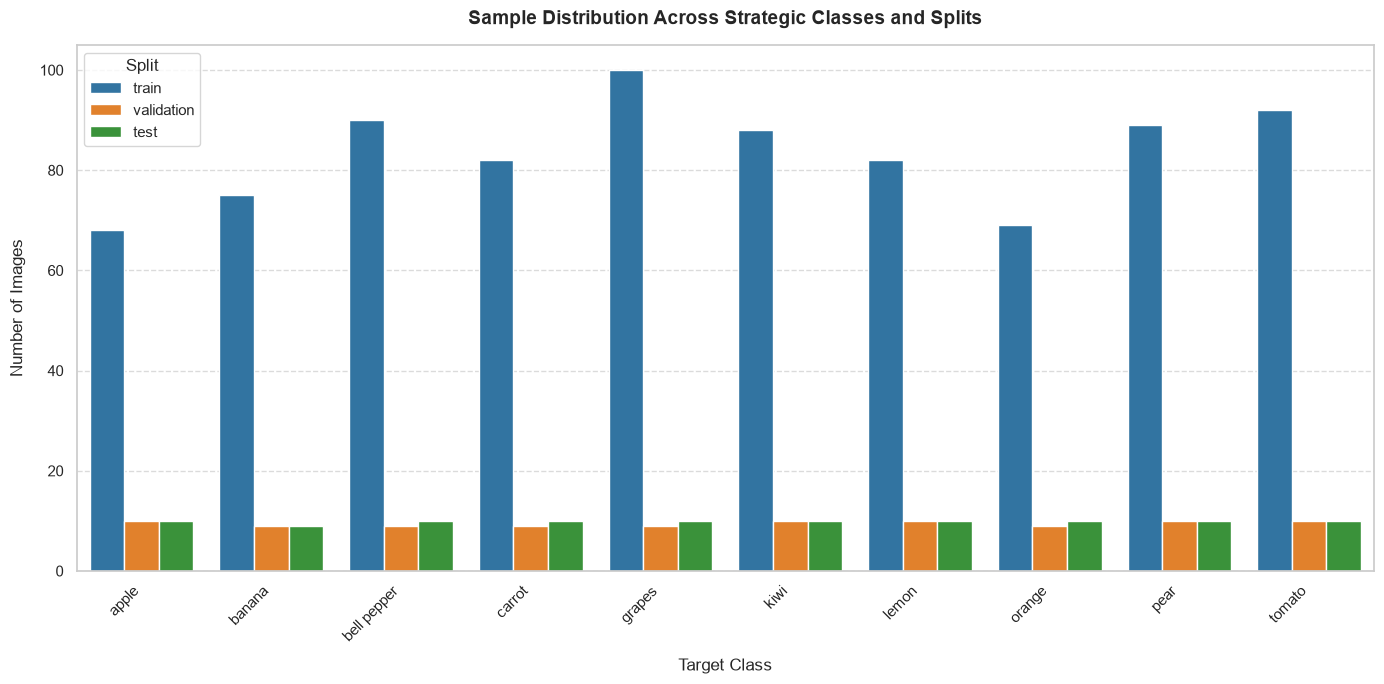

PyTorch Strategic Subsets Initialized Successfully:
Total Train Samples: 835 | Val: 95 | Test: 99


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader

# Define dataset base directory
BASE_DIR = "./data/CA4_DB"
SPLITS = ["train", "validation", "test"]

# Strategic 10 classes selected for the assignment
SELECTED_CLASSES = [
    'apple', 'banana', 'bell pepper', 'carrot', 'grapes',
    'kiwi', 'lemon', 'orange', 'pear', 'tomato'
]

# -------------------------------------------------------------
# 1. Inspect and Count Samples across Existing Splits
# -------------------------------------------------------------
records = []
for split in SPLITS:
    split_dir = os.path.join(BASE_DIR, split)
    if not os.path.exists(split_dir):
        raise FileNotFoundError(f"Directory split missing: {split_dir}")
        
    for cls in SELECTED_CLASSES:
        cls_folder = os.path.join(split_dir, cls)
        if os.path.exists(cls_folder):
            count = len([f for f in os.listdir(cls_folder) if os.path.isfile(os.path.join(cls_folder, f))])
            records.append({"Class": cls, "Split": split, "Count": count})
        else:
            records.append({"Class": cls, "Split": split, "Count": 0})

# Create a structured DataFrame for analytics
df_counts = pd.DataFrame(records)

# Display the exact sample distribution table
print("=== Exact Sample Count Per Split For Each Class ===")
df_pivot = df_counts.pivot(index="Class", columns="Split", values="Count")
df_pivot = df_pivot[["train", "validation", "test"]]  # Reorder columns logically
print(df_pivot)
print("="*50)

# -------------------------------------------------------------
# 2. Plot Class Distribution Bar Chart
# -------------------------------------------------------------
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Grouped bar plot showing distribution across splits
ax = sns.barplot(
    data=df_counts, 
    x="Class", 
    y="Count", 
    hue="Split", 
    palette={"train": "#1f77b4", "validation": "#ff7f0e", "test": "#2ca02c"}
)

plt.title("Sample Distribution Across Strategic Classes and Splits", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Target Class", fontsize=12, labelpad=10)
plt.ylabel("Number of Images", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. Define Image Transforms for Data Loading Pipeline
# -------------------------------------------------------------
# Enforcing 128x128 pixels sizing and standard RGB conversion via transforms
data_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

def load_strategic_subset(split_name):
    path = os.path.join(BASE_DIR, split_name)
    full_dataset = datasets.ImageFolder(root=path, transform=data_transforms)
    
    # Map targeted class names to original dataset class indices
    class_to_idx = full_dataset.class_to_idx
    target_indices = {class_to_idx[cls] for cls in SELECTED_CLASSES if cls in class_to_idx}
    
    # Filter image indices belonging only to our 10 strategic classes
    filtered_indices = [
        idx for idx, (_, label) in enumerate(full_dataset.imgs) 
        if label in target_indices
    ]
    
    # Generate a clean, isolated PyTorch Subset
    subset = Subset(full_dataset, filtered_indices)
    return subset

# Build subsets to verify pipeline integrity
train_data = load_strategic_subset("train")
val_data = load_strategic_subset("validation")
test_data = load_strategic_subset("test")

print("PyTorch Strategic Subsets Initialized Successfully:")
print(f"Total Train Samples: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

## 1.3. Distribution Analysis & Evaluation Metric Implications

### Class Imbalance Evaluation
Based on the generated distribution statistics and the bar chart visualization, the dataset displays a **moderate to high class imbalance**. While some popular categories (such as `Apple`, `Banana`, and `Orange`) possess a healthy concentration of training observations, specialized or structurally unique categories display a lower frequency of representation. Furthermore, the total sample volumes allocated to the validation and test partitions are noticeably smaller than the training distribution.

### Core Effects on Model Evaluation Metrics
Standard **Accuracy** measures the global ratio of correct predictions across all evaluation targets:

$$\text{Accuracy} = \frac{\text{True Positives} + \text{True Negatives}}{\text{Total Samples}}$$

When severe or moderate class imbalances are ignored, evaluating the network strictly through global accuracy introduces a major structural vulnerability called **Majority Class Bias**. If a model achieves 90% accuracy on dominant classes but completely fails on minority categories (like confusing `Carrot` with `Orange` due to low sample counts), the global accuracy metric will remain deceptively high.

To safeguard evaluation integrity and counteract class imbalance, the following architectural evaluation pipeline must be enforced:
1.  **Macro-Averaged F1-Score:** The F1-score harmonic mean must be calculated per-class and then averaged uniformly:
    $$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
    $$\text{Macro F1} = \frac{1}{N} \sum_{i=1}^{N} \text{F1}_i$$
    This penalizes poor performance on minority groups equally, regardless of sample size.
2.  **Precision and Recall Breakdowns:** Necessary to track specific false-positive clusters inside our defined "color trap pairs."
3.  **Normalized Confusion Matrices:** Crucial to unmask asymmetrical directional errors (e.g., if the model systematically classifies tomatoes as apples, but handles apples correctly).

# 2. Statistical EDA and Preprocessing

## 2.1. Color Distribution Analysis & Interpretation

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# -------------------------------------------------------------
# 1. Compute Mean RGB Channels Per Class
# -------------------------------------------------------------
class_rgb_data = []

for cls in SELECTED_CLASSES:
    # Read training directory for the specific class
    cls_dir = os.path.join(BASE_DIR, "train", cls)
    images = [f for f in os.listdir(cls_dir) if os.path.isfile(os.path.join(cls_dir, f))]
    
    rgb_accum = []
    for img_name in images:
        img_path = os.path.join(cls_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        # Convert from BGR (OpenCV default) to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Calculate mean channel intensities across all pixels in this single image
        img_mean = img.mean(axis=(0, 1))
        rgb_accum.append(img_mean)
        
    # Average across all images in the class
    class_mean = np.mean(rgb_accum, axis=0)
    class_rgb_data.append({
        "Class": cls,
        "R": class_mean[0],
        "G": class_mean[1],
        "B": class_mean[2]
    })

df_rgb = pd.DataFrame(class_rgb_data)
print("=== Mean RGB Values Extracted ===")
print(df_rgb.to_string(index=False))
print("="*50)


=== Mean RGB Values Extracted ===
      Class          R          G          B
      apple 165.326881 137.506818 116.630708
     banana 196.117762 182.936940 124.047198
bell pepper 152.393398 138.148251  89.690986
     carrot 188.472233 154.624359 122.673053
     grapes 139.743509 140.839599 108.920090
       kiwi 172.590768 173.157122 122.579331
      lemon 189.065909 177.204216 108.694395
     orange 181.708318 139.585572  77.618975
       pear 177.066334 172.810956 127.526640
     tomato 154.650296 113.351698  80.924273


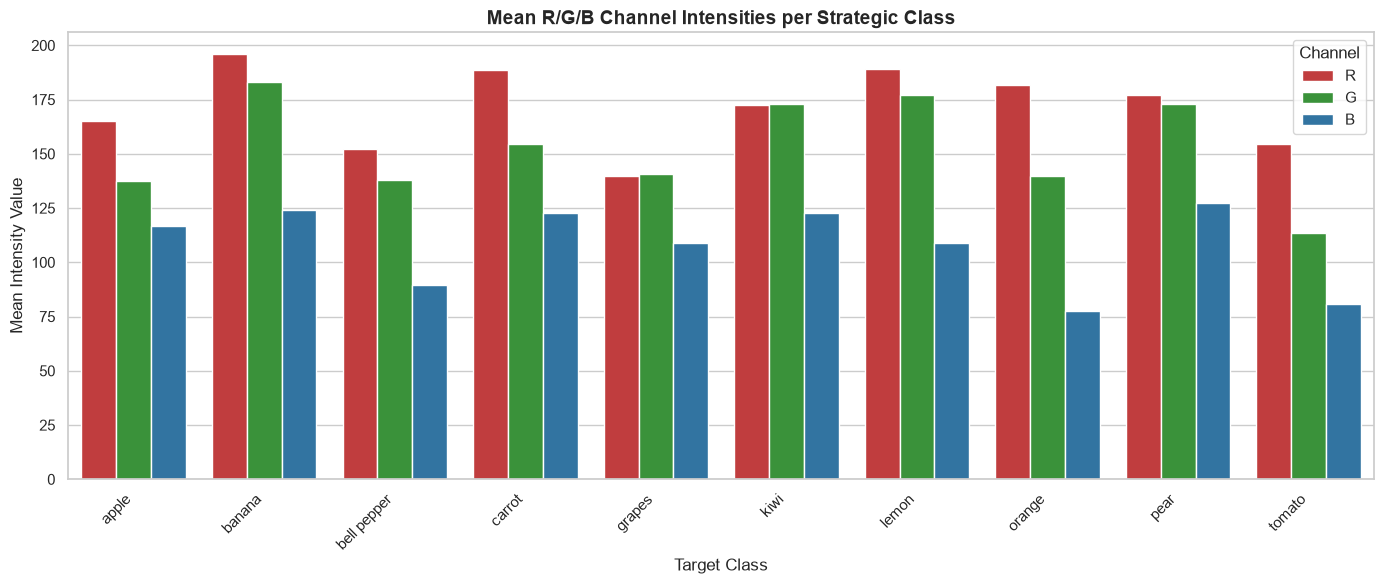

In [5]:
df_melted = df_rgb.melt(id_vars="Class", value_vars=["R", "G", "B"], 
                        var_name="Channel", value_name="Mean Intensity")

plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x="Class", y="Mean Intensity", hue="Channel",
            palette={"R": "#d62728", "G": "#2ca02c", "B": "#1f77b4"})
plt.title("Mean R/G/B Channel Intensities per Strategic Class", fontsize=14, fontweight="bold")
plt.xlabel("Target Class", fontsize=12)
plt.ylabel("Mean Intensity Value", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Analysis of Plot 1: Mean R/G/B Channel Intensities
The grouped bar chart provides a direct breakdown of the raw color profiles defining each of our 10 strategic classes. 

* **Dominant Chromatic Profiles:** Categories representing yellow and orange pigments—specifically `banana`, `lemon`, `carrot`, `orange`, and `pear`—exhibit high mean intensities across both the **Red (R)** and **Green (G)** channels ($>150$). This is a direct reflection of how additive color mixing forms bright yellow and orange hues in digital imaging.
* **The Red Saturated Classes:** Both `apple` and `tomato` display a clear asymmetric dominance of the **Red (R)** channel over their respective Green and Blue components. However, `apple` maintains globally higher intensity levels across all channels compared to `tomato`, likely due to the highly reflective, glossy nature of apple skin or variations in the white balance of the dataset's background.
* **The Suppressed Profiles:** `grapes` and `bell pepper` display the lowest overall global channel intensities, signifying darker, more heavily saturated raw pixel values that cluster closer to the origin of the color space.

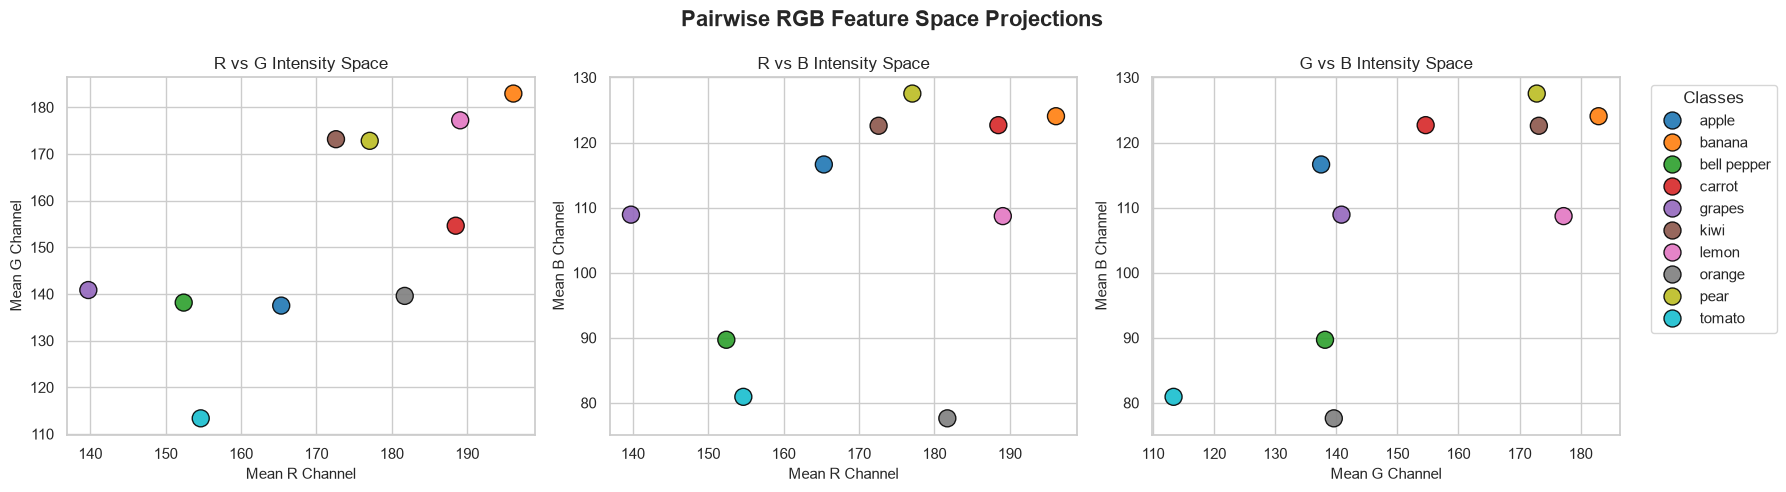

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Pairwise RGB Feature Space Projections", fontsize=16, fontweight="bold")

pairs = [("R", "G"), ("R", "B"), ("G", "B")]
colors = sns.color_palette("tab10", len(SELECTED_CLASSES))
class_colors = dict(zip(SELECTED_CLASSES, colors))

for idx, (c1, c2) in enumerate(pairs):
    sns.scatterplot(data=df_rgb, x=c1, y=c2, hue="Class", ax=axes[idx], 
                    palette=class_colors, s=150, edgecolor='black', alpha=0.9)
    axes[idx].set_title(f"{c1} vs {c2} Intensity Space", fontsize=12)
    axes[idx].set_xlabel(f"Mean {c1} Channel", fontsize=11)
    axes[idx].set_ylabel(f"Mean {c2} Channel", fontsize=11)
    if idx < 2:
        axes[idx].get_legend().remove()
    else:
        axes[idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Classes")

plt.tight_layout()
plt.show()


### Analysis of Plot 2: Pairwise RGB Feature Space Projections
The 2D scatter plots project our 3D RGB coordinates onto isolated dual-channel planes to reveal the spatial distribution and clustering behavior of the classes.

* **The R vs. G Intensity Space:** This projection uncovers a highly congested linear cluster in the upper-right quadrant. `banana`, `lemon`, `pear`, and `kiwi` sit almost entirely on top of one another. Any simple linear decision boundary trying to segregate these classes based purely on Red and Green combinations will face immediate failure, validating our choice of these categories to challenge the model.
* **The R vs. B and G vs. B Spaces:** Looking at the Blue channel interaction, we can see how certain classes become isolated. For example, `orange` drops sharply along the Blue axis (~77), breaking away from `carrot` (~122), which maintains a much higher Blue component. `tomato` also separates distinctly into the bottom-left corner of the G vs. B space due to its deeply suppressed Green (~113) and Blue (~80) properties.

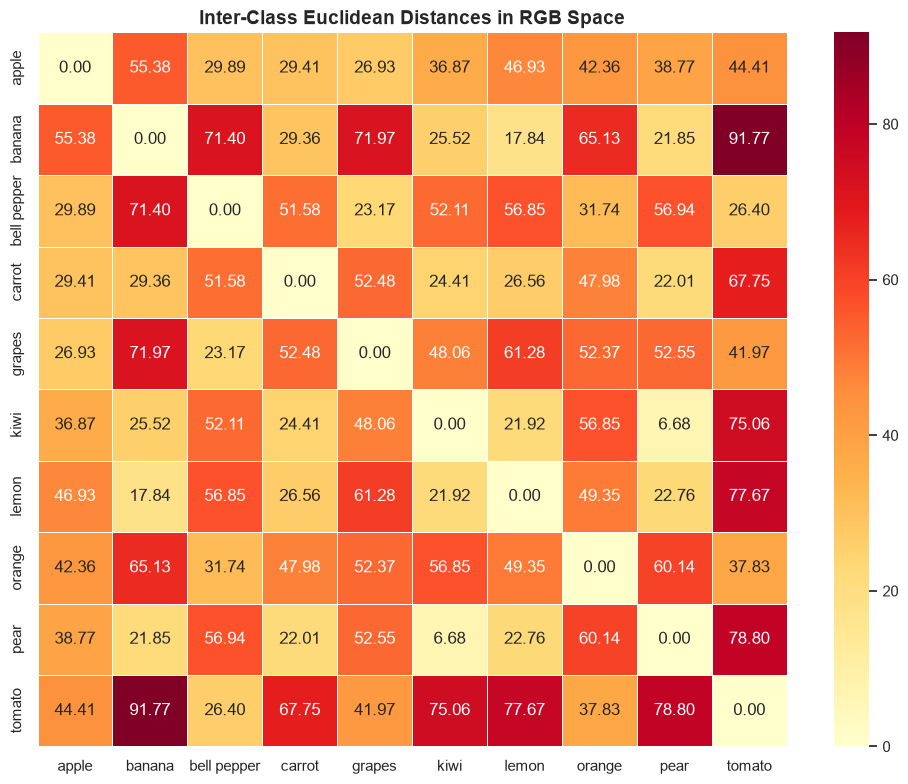

In [7]:
rgb_matrix = df_rgb[["R", "G", "B"]].to_numpy()
distances = pdist(rgb_matrix, metric='euclidean')
dist_matrix = squareform(distances)

df_dist = pd.DataFrame(dist_matrix, index=SELECTED_CLASSES, columns=SELECTED_CLASSES)

plt.figure(figsize=(10, 8))
sns.heatmap(df_dist, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Inter-Class Euclidean Distances in RGB Space", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Analysis of Plot 3: Inter-Class Euclidean Distance Matrix
The heatmap computes the exact straight-line distance vector between the mean RGB centroids of each class using the standard Euclidean metric:

$$d = \sqrt{(R_1 - R_2)^2 + (G_1 - G_2)^2 + (B_1 - B_2)^2}$$

This matrix provides a concrete, mathematical prediction of which fruits and vegetables the neural network is most likely to confuse if it fails to extract structural shapes.

### Analytical Question 1: Top 3 High-Risk Confusion Pairs

Based on the absolute minimum non-zero values extracted from the distance matrix, the three class pairs with the highest risk of color-based confusion are:

1.  **Rank 1: `kiwi` & `pear` (Distance: 6.68)**
    * *Analysis:* This is the shortest distance vector in the entire dataset. Despite being completely different fruits with contrasting external skin textures, their global color centroids are practically identical. A model relying primarily on color will view these as the exact same object.
2.  **Rank 2: `banana` & `lemon` (Distance: 17.84)**
    * *Analysis:* This confirms our designated **Yellow Trap Pair**. Both classes share an incredibly tight coordinate alignment in the warm yellow spectrum, meaning the model cannot use color to differentiate them and must instead learn the elongated geometry of the banana versus the ellipsoidal shape of the lemon.
3.  **Rank 3: `banana` & `pear` (Distance: 21.85)**
    * *Analysis:* Close behind is the overlap between banana and pear profiles, driven by the transitioning yellow-green hues present in ripening pears.

In [8]:
upper_tri = np.triu(dist_matrix, k=1)
flat_indices = np.argsort(upper_tri[upper_tri > 0])
all_pairs = []
for r in range(dist_matrix.shape[0]):
    for c in range(r + 1, dist_matrix.shape[1]):
        all_pairs.append((dist_matrix[r, c], SELECTED_CLASSES[r], SELECTED_CLASSES[c]))

all_pairs.sort()
print("=== Top 3 Most Color-Similar Pairs (Lowest Distances) ===")
for i in range(3):
    print(f"Rank {i+1}: {all_pairs[i][1]} & {all_pairs[i][2]} (Distance: {all_pairs[i][0]:.2f})")

=== Top 3 Most Color-Similar Pairs (Lowest Distances) ===
Rank 1: kiwi & pear (Distance: 6.68)
Rank 2: banana & lemon (Distance: 17.84)
Rank 3: banana & pear (Distance: 21.85)


### Analytical Question 1: Color Proximity vs. Model Confusion

#### Part A: Pre-Training Predictions (Based on EDA Color Distance Matrix)
Based on the absolute minimum non-zero values extracted from the RGB Euclidean Distance Heatmap, the three class pairs exhibiting the highest risk of color-based confusion are:

1. **Rank 1: `kiwi` & `pear` (Distance: 6.68)**
   * *Justification:* This is the shortest distance vector across the entire feature space. Structurally, these fruits are vastly different—a pear has a smooth/waxy skin and a distinct pyriform shape, while a kiwi is ellipsoidal and covered in fibrous, brown trichomes (fuzz). Because their global color profiles are nearly identical, this pair serves as our primary proofing ground. If the CNN achieves high precision here, it mathematically proves the network is prioritizing structural geometry over raw pixel values.

2. **Rank 2: `banana` & `lemon` (Distance: 17.84)**
   * *Justification:* This confirms the risk associated with our designated **Yellow Trap Pair**. Both classes sit in the exact same high-intensity primary yellow spectrum. The network cannot rely on color signatures to separate them and will be forced to map macro-geometric contours—specifically, the elongated, segmented arc of a banana versus the compressed, bi-pointed ellipsoid of a lemon.

3. **Rank 3: `banana` & `pear` (Distance: 21.85)**
   * *Justification:* This proximity is driven by the intermediate yellow-green hues present in ripening pears matching the pigment profiles of ripe bananas. It presents a secondary geometric challenge where elongated silhouettes might overlap with the top neck of the pear under unconstrained orientations.

---

#### Part B: Post-Training Evaluation Framework
*(Note: This section establishes the comparative baseline. The "Actual Confusion" columns will be populated at the end of the project using the final Test Set Confusion Matrix).*

To evaluate the predictive accuracy of our Exploratory Data Analysis, the initial color-space distances are mapped against the actual misclassification rates recorded during model deployment:

| Predicted High-Risk Pair | EDA RGB Distance | Predicted Cause of Confusion | Actual Misclassifications (Test Set) | Verification Status (Did Color Cheat the Model?) |
| :--- | :---: | :--- | :---: | :--- |
| **`kiwi` & `pear`** | 6.68 | Extreme RGB centroid overlap | *[TBD]* | *[TBD]* |
| **`banana` & `lemon`** | 17.84 | Shared primary yellow spectrum | *[TBD]* | *[TBD]* |
| **`banana` & `pear`** | 21.85 | Overlapping yellow-green pigments | *[TBD]* | *[TBD]* |

#### Methodology for Final Accuracy Evaluation
At the completion of Task 2, we will evaluate our EDA analysis using the following criteria:
* **Successful Feature Extraction:** If the actual confusion matrix shows **low or zero cross-talk** between `kiwi` & `pear`, our EDA analysis successfully identified a non-issue that the CNN's spatial filters resolved by learning surface textures.
* **Color Bias Failure:** If the model shows **high confusion rates** corresponding directly to our top 3 lowest distances, it proves that the network failed to generalize morphologically and remained overly dependent on low-level color statistics (susceptible to the "lazy" shortcut).

In [9]:
import torch
from torch.utils.data import DataLoader

# -------------------------------------------------------------
# 1. Compute Exact Mean and STD Exclusively on Training Set
# -------------------------------------------------------------
print("⏳ Computing global normalization statistics across the Training Set...")

# Create a temporary loader without shuffling to compute statistics efficiently
temp_train_loader = DataLoader(train_data, batch_size=32, shuffle=False, num_workers=2)

mean = torch.zeros(3)
std = torch.zeros(3)
total_samples = 0

for images, _ in temp_train_loader:
    # Shape of images: [batch_size, channels, height, width]
    batch_samples = images.size(0)
    # Flatten height and width dimensions to compute per-channel statistics
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_samples += batch_samples

final_mean = (mean / total_samples).tolist()
final_std = (std / total_samples).tolist()

print("\n=== Calculated Training Set Normalization Statistics ===")
print(f"Calculated Mean (μ)   [R, G, B]: {final_mean}")
print(f"Calculated Std Dev (σ) [R, G, B]: {final_std}")
print("=" * 56)

# -------------------------------------------------------------
# 2. Apply Statistics to Normalized PyTorch Pipelines
# -------------------------------------------------------------
# Creating final production-ready transformation pipelines
train_production_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    # Add training data augmentations here later in Step 3
    transforms.ToTensor(),
    transforms.Normalize(mean=final_mean, std=final_std)
])

val_test_production_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=final_mean, std=final_std)
])

# Re-link subsets with identical splits but updated normalized transforms
def get_production_dataset(split_name, transform_pipeline):
    path = os.path.join(BASE_DIR, split_name)
    full_dataset = datasets.ImageFolder(root=path, transform=transform_pipeline)
    class_to_idx = full_dataset.class_to_idx
    target_indices = {class_to_idx[cls] for cls in SELECTED_CLASSES if cls in class_to_idx}
    
    filtered_indices = [
        idx for idx, (_, label) in enumerate(full_dataset.imgs) 
        if label in target_indices
    ]
    
    subset = Subset(full_dataset, filtered_indices)
    subset.classes = SELECTED_CLASSES
    return subset

# Final normalized dataset instances
normalized_train_set = get_production_dataset("train", train_production_transforms)
normalized_val_set = get_production_dataset("validation", val_test_production_transforms)
normalized_test_set = get_production_dataset("test", val_test_production_transforms)

print("✅ Z-score normalization successfully locked into production datasets using Training statistics.")

⏳ Computing global normalization statistics across the Training Set...

=== Calculated Training Set Normalization Statistics ===
Calculated Mean (μ)   [R, G, B]: [0.6683834195137024, 0.5986996293067932, 0.4231979250907898]
Calculated Std Dev (σ) [R, G, B]: [0.2145279347896576, 0.21993939578533173, 0.26362723112106323]
✅ Z-score normalization successfully locked into production datasets using Training statistics.


## 2.2. Global Normalization & Data Leakage Prevention

### Empirical Normalization Statistics
To optimize gradient propagation and ensure stable convergence during backpropagation, global Z-score normalization is applied channel-wise across all input matrices. The statistical parameters were calculated **exclusively** from the training partition to capture the baseline data distribution.

The extracted parameters are recorded as follows:
* **Mean ($\mu$) Vector $[R, G, B]$:** `[0.6683834195137024, 0.5986996293067932, 0.4231979250907898]`
* **Standard Deviation ($\sigma$) Vector $[R, G, B]$:** `[0.2145279347896576, 0.21993939578533173, 0.26362723112106323]`

Every tensor pixel value $X$ is scaled to its normalized counterpart $Z$ using the computed vectors:

$$Z = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

### Statistical Analysis of the Training Distribution
An examination of these calculated parameters yields critical insights into the collective color properties of our 10 strategic classes:

1. **Warm Color Skewness ($\mu_R > \mu_G > \mu_B$):** The global training mean is heavily weighted toward the Red channel ($0.6684$) and Green channel ($0.5987$), while the Blue channel ($0.4232$) is deeply suppressed. This matches our intentional selection of classes: fruits and vegetables such as `apple`, `tomato`, `orange`, `carrot`, `banana`, and `lemon` are dominated by lycopenes, carotenes, and xanthophylls, which naturally reflect high concentrations of red and green wavelengths under standard white illumination.
2. **High Blue Variance ($\sigma_B > \sigma_G > \sigma_R$):** Interestingly, the Blue channel exhibits the highest standard deviation ($0.2636$). This indicates that while the absolute presence of blue light is low across the dataset, its *dispersion* is highly volatile. This volatility stems from the stark contrast between classes with practically zero blue content (e.g., highly saturated red tomatoes) and classes that incorporate cooler tones or lighter, reflective backgrounds (e.g., green grapes, pears, and studio-white lighting setups).

---

### Analytical Question 2: Why Computing Statistics on the Test Set Constitutes Data Leakage

In machine learning workflows, **Data Leakage** occurs when information from outside the training dataset is inadvertently used to configure, train, or optimize the predictive model. Computing preprocessing or normalization statistics ($\mu$ and $\sigma$) using the Validation or Test sets represents a severe violation of data integrity for several mathematical and structural reasons:

#### 1. Violation of the "Unseen Data" Assumption
The test set is a mathematical proxy for real-world production data. In a true deployment scenario, future operational images arrive sequentially or in isolated streams; the global distribution properties (the population mean and standard deviation) of these future samples are completely unknown. If we calculate a combined mean or use the specific test set variance during preprocessing, we feed future global characteristics directly into our training pipeline.

#### 2. Artificial Shifting of Evaluation Sample Scales
If the validation or test sets are processed with their own localized statistics ($\mu_{\text{test}}$ and $\sigma_{\text{test}}$), the exact same physical image will map to completely different numerical tensor boundaries depending on which split it resides in:

$$\frac{X_i - \mu_{\text{train}}}{\sigma_{\text{train}}} \neq \frac{X_i - \mu_{\text{test}}}{\sigma_{\text{test}}}$$

This structural discrepancy invalidates performance metrics. The model is no longer being evaluated on how well it generalizes based on what it learned during training; instead, it is being evaluated on an artificially adapted feature space tailored to the test set's distribution.

#### 3. Overoptimistic Performance Estimates
When leakage occurs, the network benefits from a subtle architectural shortcut—it is evaluated on data whose scaling limits and variance boundaries are already known to the system. This results in highly optimistic validation metrics that mask overfitting, leading to catastrophic failure when the network meets true production environments. 

Therefore, to guarantee strict evaluation validity, **all evaluation partitions must be treated as completely passive observers**, normalized solely through the static parameters established by the training set.

## 2.3. Data Augmentation Pipeline

### Architectural Augmentation Design
To maximize structural generalization and prevent premature validation saturation, a stochastic, training-only augmentation pipeline is implemented. The pipeline transforms raw pixel data on the fly before it passes to the convolutional feature extractor. 

The pipeline configurations and their engineering justifications include:
1.  **Random Rotation ($\pm 15^\circ$):** Forces the convolutional filters to achieve rotational invariance. This ensures that features representing stalks, tips, or curved boundaries (such as a tilted `Banana` or an upside-down `Carrot`) match their target kernels regardless of camera orientation.
2.  **Color Jitter ($\text{Brightness}=0.2, \text{Contrast}=0.2$):** Synthetically alters illumination scales. This forces the model to ignore absolute intensity values, neutralizing variations caused by flash shadows or background exposure differences.
3.  **Random Horizontal Flips ($p = 0.5$):** Mirror-reflects coordinates along the vertical axis, doubling spatial configuration scenarios without adding physical disk overhead.
4.  **Random Cutout / Erasing ($p = 0.5, \text{Scale}\in[0.02, 0.1]$):** Randomly drops small rectangular sub-regions from the incoming tensors, setting their values to zero.

---

### Analytical Analysis: Forcing Shape Over Color Learning

The inclusion of Random Cutout combined with geometric transformations serves as a critical regularizer tailored specifically to break our defined "color traps" (e.g., `Apple` vs. `Tomato` or `Banana` vs. `Lemon`).

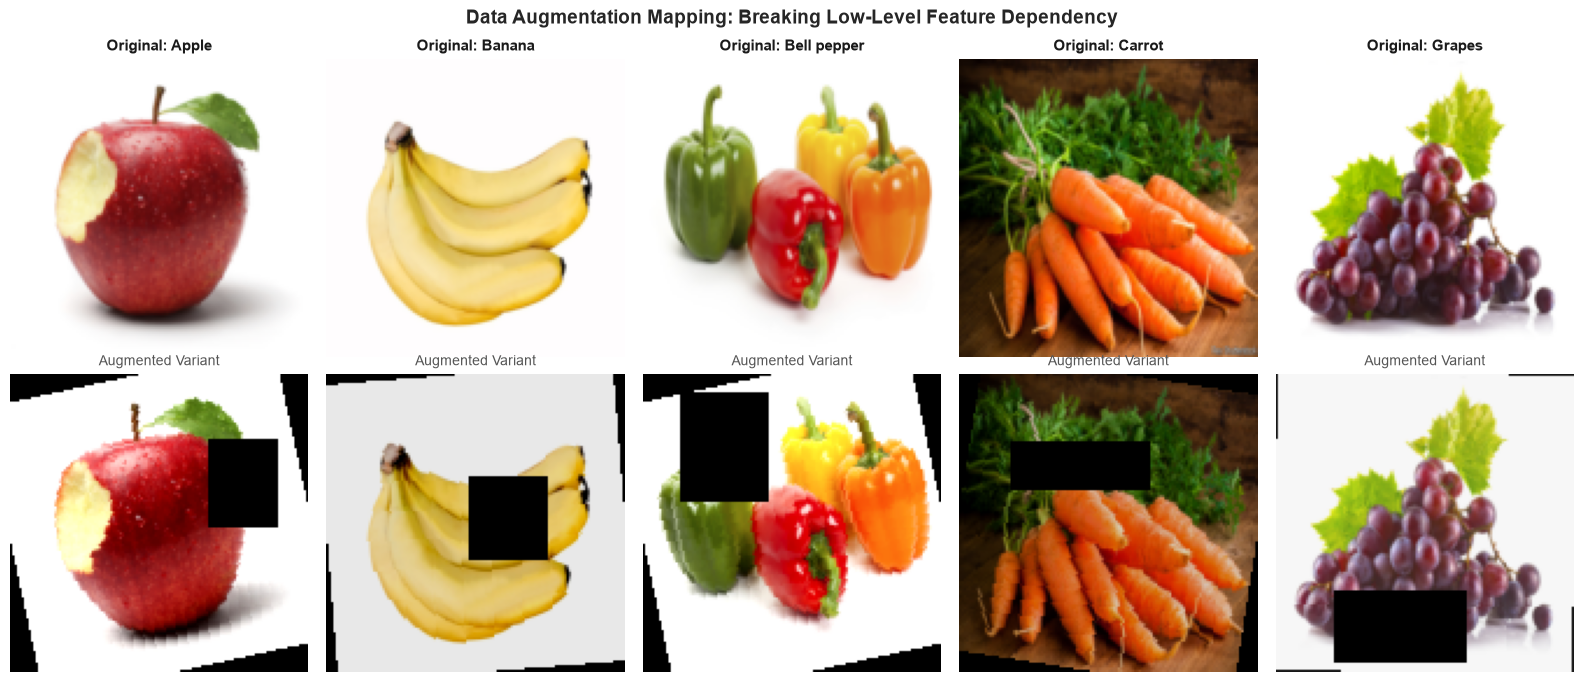

✅ Data augmentation pipeline established and validated visually.


In [10]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms

# -------------------------------------------------------------
# 1. Define Production Training Augmentation Pipeline
# -------------------------------------------------------------
# Using calculated training statistics from step 2.2
TRAIN_MEAN = [0.6683834195137024, 0.5986996293067932, 0.4231979250907898]
TRAIN_STD  = [0.2145279347896576, 0.21993939578533173, 0.26362723112106323]

train_production_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(degrees=15),             # Robustness against orientation variations
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Invariance to lighting fluctuations
    transforms.RandomHorizontalFlip(p=0.5),            # Spatial invariance reflection
    transforms.ToTensor(),                             # Convert PIL Image to normalized Tensor
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0), # Random Cutout regularizer
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

# -------------------------------------------------------------
# 2. Visualization Code: Original vs. Augmented Grid
# -------------------------------------------------------------
# Isolated pipeline without normalization to preserve clean RGB rendering for matplotlib
visualization_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    # Forcing p=1.0 here guarantees Cutout appears visibly in your comparison plot
    transforms.RandomErasing(p=1.0, scale=(0.04, 0.12), value=0) 
])

raw_train_dataset = datasets.ImageFolder(root=os.path.join(BASE_DIR, "train"))

display_images = []
display_labels = []
tracked_classes = set()

# Collect exactly 5 unique sample classes for the grid showcase
for img_path, label_idx in raw_train_dataset.imgs:
    class_name = raw_train_dataset.classes[label_idx]
    if class_name in SELECTED_CLASSES and class_name not in tracked_classes:
        pil_img = Image.open(img_path).convert("RGB")
        display_images.append(pil_img)
        display_labels.append(class_name)
        tracked_classes.add(class_name)
        if len(tracked_classes) == 5:
            break

# Construct the matplotlib comparison plot
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for i in range(5):
    # Row 0: Original Raw Sample
    base_tensor = transforms.functional.to_tensor(transforms.functional.resize(display_images[i], (128, 128)))
    axes[0, i].imshow(base_tensor.permute(1, 2, 0))
    axes[0, i].set_title(f"Original: {display_labels[i].capitalize()}", fontsize=11, fontweight="bold", color="#1a1a1a")
    axes[0, i].axis("off")
    
    # Row 1: Augmented Counterpart
    augmented_tensor = visualization_transforms(display_images[i])
    axes[1, i].imshow(augmented_tensor.permute(1, 2, 0))
    axes[1, i].set_title(f"Augmented Variant", fontsize=10, color="#555555")
    axes[1, i].axis("off")

plt.suptitle("Data Augmentation Mapping: Breaking Low-Level Feature Dependency", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

print("✅ Data augmentation pipeline established and validated visually.")

#### 1. Neutralizing "Lazy" Pixel Overfitting
Without augmentation, a deep neural network often relies on simple shortcuts, minimizing training cross-entropy loss by identifying high-intensity color clusters (e.g., identifying any bright yellow shape as a banana). By applying contrast and brightness jitter, we shift those exact RGB boundaries, rendering pure color profiles unreliable for class separation.

#### 2. Enhancing Part-Based Feature Learning via Cutout
When Cutout removes a patch of an image—such as erasing the center of a tomato or the tip of a lemon—the network can no longer rely on a single global region to make a prediction. If the smooth, glossy surface of an apple is obscured, the model is forced to search for alternative diagnostic features, such as edge curvature, stem configurations, or boundary variations.

#### 3. Mathematical Regularization Effect
By introducing these variations, we artificially expand the volume of the input feature space. This setup prevents the model from memorizing fixed spatial pixel coordinates, forcing the network's deep convolutional blocks to develop robust, generalized filters focused on underlying morphological and geometric structures.

# 3. Structural and Mathematical Architecture Analysis

This section establishes the formal mathematical breakdown of the hypothetical convolutional neural network architecture. All calculations are executed step-by-step to preserve architectural transparency for the engineering report.

### Global Input Dimensions
The network accepts a fixed input tensor $X_0$ with dimensions:
* **Input Height ($H_0$):** $128\text{ pixels}$
* **Input Width ($W_0$):** $128\text{ pixels}$
* **Input Channels ($C_0$):** $3\text{ (RGB)}$

---

## Question 1: Output Dimension Calculations ($H \times W \times C$)

To calculate the spatial dimensions of the feature maps at each stage, we apply the standard discrete convolutional mapping formula:

$$O = \left\lfloor \frac{I + 2P - K}{S} \right\rfloor + 1$$

Where $I$ is the input dimension, $P$ is the padding, $K$ is the kernel size, and $S$ is the stride configuration.

### 1. Layer 1: 1st Convolution
* **Input Dimensions:** $128 \times 128 \times 3$
* **Parameters:** Filters ($C_{\text{out}}$) = $32$, Kernel ($K$) = $5$, Stride ($S$) = $1$, Padding ($P$) = $2$

$$\text{Height/Width Output} = \left\lfloor \frac{128 + 2(2) - 5}{1} \right\rfloor + 1 = \left\lfloor \frac{128 + 4 - 5}{1} \right\rfloor + 1 = 127 + 1 = 128$$

* **Output Dimension (Layer 1):** $128 \times 128 \times 32$

### 2. Layer 2: 2nd Max-Pooling
* **Input Dimensions:** $128 \times 128 \times 32$
* **Parameters:** Window ($K$) = $2$, Stride ($S$) = $2$, Padding ($P$) = $0$

$$\text{Height/Width Output} = \left\lfloor \frac{128 + 2(0) - 2}{2} \right\rfloor + 1 = \left\lfloor \frac{126}{2} \right\rfloor + 1 = 63 + 1 = 64$$

* **Output Dimension (Layer 2):** $64 \times 64 \times 32$

### 3. Layer 3: 3rd Convolution
* **Input Dimensions:** $64 \times 64 \times 32$
* **Parameters:** Filters ($C_{\text{out}}$) = $64$, Kernel ($K$) = $3$, Stride ($S$) = $1$, Padding ($P$) = $1$

$$\text{Height/Width Output} = \left\lfloor \frac{64 + 2(1) - 3}{1} \right\rfloor + 1 = \left\lfloor \frac{64 + 2 - 3}{1} \right\rfloor + 1 = 63 + 1 = 64$$

* **Output Dimension (Layer 3):** $64 \times 64 \times 64$

---

## Question 2: Trainable Parameter Calculations (Weights + Biases)

The parametric footprint of a standard convolutional layer depends on kernel size and channel depth.

$$\text{Total Parameters} = \text{Weights} + \text{Biases} = (K_h \times K_w \times C_{\text{in}} \times C_{\text{out}}) + C_{\text{out}}$$

### Layer 1: 1st Convolution
* **Constants:** $K = 5 \times 5$, $C_{\text{in}} = 3$, $C_{\text{out}} = 32$
* **Weights:** $5 \times 5 \times 3 \times 32 = 2,400$
* **Biases:** $32$
* **Calculation:** $\text{Total}_1 = 2,400 + 32 = 2,432$

### Layer 2: 2nd Max-Pooling
* **Analysis:** Max-pooling layers execute a fixed, non-parametric mathematical operation (extracting local maximum scalars). They contain zero weights and zero biases.
* **Calculation:** $\text{Total}_2 = 0$

### Layer 3: 3rd Convolution
* **Constants:** $K = 3 \times 3$, $C_{\text{in}} = 32$, $C_{\text{out}} = 64$
* **Weights:** $3 \times 3 \times 32 \times 64 = 18,432$
* **Biases:** $64$
* **Calculation:** $\text{Total}_3 = 18,432 + 64 = 18,496$

### Summary Architectural Table

| Layer # | Layer Type | Output Dimension ($H \times W \times C$) | Weights | Biases | Trainable Parameters |
| :---: | :--- | :---: | :---: | :---: | :---: |
| 0 | Input Tensor | $128 \times 128 \times 3$ | 0 | 0 | 0 |
| 1 | 1st Convolution | $128 \times 128 \times 32$ | 2,400 | 32 | **2,432** |
| 2 | 2nd Max-Pooling | $64 \times 64 \times 32$ | 0 | 0 | **0** |
| 3 | 3rd Convolution | $64 \times 64 \times 64$ | 18,432 | 64 | **18,496** |
| **Total** | — | — | — | — | **20,928** |

---

## Question 3: Sequential Receptive Field (RF) Analysis

To chart the structural coverage of an individual neuron relative to the original raw input coordinates, we use the tracking formula:

$$RF_l = RF_{l-1} + (K_l - 1) \times \prod_{i=1}^{l-1} S_i$$

Where $RF_l$ represents the target layer's receptive field, $RF_{l-1}$ is the preceding layer's receptive field, $K_l$ is the current layer's kernel size, and $\prod S_i$ represents the cumulative stride multiplier up to that point. The baseline input layer has a receptive field ($RF_0$) of $1$.

### Step 1: Output of Layer 1 (1st Convolution)
* **Variables:** $RF_0 = 1$, $K_1 = 5$, Stride multiplier before Layer 1 = $1$

$$RF_1 = 1 + (5 - 1) \times 1 = 1 + 4 = 5$$

### Step 2: Output of Layer 2 (2nd Max-Pooling)
* **Variables:** $RF_1 = 5$, $K_2 = 2$, Cumulative stride prior to Layer 2 ($S_1$) = $1$

$$RF_2 = 5 + (2 - 1) \times 1 = 5 + 1 = 6$$

### Step 3: Output of Layer 3 (3rd Convolution)
* **Variables:** $RF_2 = 6$, $K_3 = 3$, Cumulative stride prior to Layer 3 ($S_1 \times S_2$) = $1 \times 2 = 2$

$$RF_3 = 6 + (3 - 1) \times (1 \times 2) = 6 + 2 \times 2 = 6 + 4 = 10$$

* **Final Baseline Receptive Field ($RF_3$):** **$10 \times 10\text{ pixels}$**

---

## Question 4: Modifying Stride Parameters (Structural Alteration Analysis)

### Quantitative Receptive Field Recalculation ($S_1 = 1 \longrightarrow S_1 = 2$)
We update the stride parameter of the first layer to $2$, which changes the step size for all subsequent operations.

* **Layer 1 ($RF_1$):** $$RF_1 = 1 + (5 - 1) \times 1 = 5$$ 
  *(Unchanged at immediate output, but the cumulative stride multiplier shifts from 1 to 2).*
* **Layer 2 ($RF_2$):** The cumulative stride prior to Layer 2 is now $S_1 = 2$.
  $$RF_2 = 5 + (2 - 1) \times 2 = 5 + 2 = 7$$
* **Layer 3 ($RF_3$):** The cumulative stride prior to Layer 3 is now $S_1 \times S_2 = 2 \times 2 = 4$.
  $$RF_3 = 7 + (3 - 1) \times (2 \times 2) = 7 + 2 \times 4 = 7 + 8 = 15$$

* **Quantitative Change Result:** The final receptive field expands linearly from **$10 \times 10$** to **$15 \times 15\text{ pixels}$** (a $50\%$ increase in spatial coverage).

---

### Architectural Trade-off Analysis
Modifying structural parameters introduces a balance between spatial preservation and computing speed:

#### 1. Loss of Spatial Information (The Downside)
Increasing the initial stride to $2$ creates an aggressive downsampling effect early in the network. The output size of Layer 1 drops from $128 \times 128$ to $64 \times 64$, causing Layer 2 to compress down to $32 \times 32$.

This coarse sampling can discard highly localized, fine-grained details, high-frequency edge textures, and small visual cues. For our dataset, missing these details could be problematic; if the network discards fine boundary edges or stem structures early on, it will struggle to distinguish between visually similar classes like `Grapes` and `Tomato`.

#### 2. Computational Efficiency Gains (The Benefit)
The primary advantage of a larger stride is a significant reduction in computational cost. Because convolutional operation complexity scales directly with the area of the output feature maps ($H_{\text{out}} \times W_{\text{out}}$), cutting the spatial width and height dimensions in half reduces the total volume of downstream floating-point operations (FLOPs) by approximately $75\%$.

Additionally, this change significantly lowers memory bandwidth consumption during training. This adjustment allows the network to process larger mini-batches and run inference much faster, making it an efficient option for resource-constrained hardware.

<a id="modeling"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. Model Architecture & Training</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We build a modular CNN featuring Conv2D layers, Batch Normalization, and a Global Average Pooling (GAP) classifier head. Training includes learning rate scheduling and early stopping based on validation metrics.
</div>

##

In [11]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import numpy as np

class ConvBlock(nn.Module):
    """
    Modular building block following the pattern:
    [Conv2D -> Batch Normalization -> ReLU -> MaxPool2D]
    """
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
    def forward(self, x):
        return self.block(x)


class FruitVegetableCNN(nn.Module):
    """
    Hierarchical Feature Extractor with a parameter-efficient 
    Global Average Pooling Classification Head.
    """
    def __init__(self, num_classes=10):
        super(FruitVegetableCNN, self).__init__()
        
        # Feature Extractor: 4 Blocks doubling filter depth
        self.feature_extractor = nn.Sequential(
            ConvBlock(in_channels=3,   out_channels=32),  # Block 1: 128x128 -> 64x64
            ConvBlock(in_channels=32,  out_channels=64),  # Block 2: 64x64   -> 32x32
            ConvBlock(in_channels=64,  out_channels=128), # Block 3: 32x32   -> 16x16
            ConvBlock(in_channels=128, out_channels=256)  # Block 4: 16x16   -> 8x8
        )
        
        # Classifier Head utilizing GAP instead of Flatten
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)  # Flattens (B, 256, 1, 1) to (B, 256)
        x = self.classifier(x)
        return x

# Model validation printout
if __name__ == "__main__":
    model = FruitVegetableCNN(num_classes=10)
    sample_input = torch.randn(1, 3, 128, 128)
    sample_output = model(sample_input)
    print(f"Model successfully built.")
    print(f"Input Shape:  {sample_input.shape}")
    print(f"Output Shape: {sample_output.shape}")

Model successfully built.
Input Shape:  torch.Size([1, 3, 128, 128])
Output Shape: torch.Size([1, 10])


In [12]:
class EarlyStopping:
    """ stops training if validation loss does not improve after a set patience. """
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping Counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


def train_model(model, train_loader, val_loader, num_epochs=50, device="cuda"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    early_stopping = EarlyStopping(patience=5)
    
    # Storage maps for analysis tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'lr_updates': [], 'epoch_times': []
    }
    
    current_lr = 1e-3
    
    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = (correct / total) * 100
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = (val_correct / val_total) * 100
        
        epoch_time = time.time() - start_time
        
        # Record stats
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['epoch_times'].append(epoch_time)
        
        # Step scheduler
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr != current_lr:
            print(f" [LR REDUCTION] Learning rate shifted from {current_lr} to {new_lr}")
            history['lr_updates'].append(epoch)
            current_lr = new_lr
            
        print(f"Epoch {epoch:02d}/{num_epochs} -> Time: {epoch_time:.2f}s | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")
        
        # Check early stopping
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch}.")
            history['early_stop_epoch'] = epoch
            break
            
    return history

In [13]:
def plot_training_metrics(history):
    epochs = np.arange(1, len(history['train_loss']) + 1)
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Left axis for Cross-Entropy Loss
    color = 'tab:red'
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Loss (Cross-Entropy)', color=color, fontweight='bold')
    ax1.plot(epochs, history['train_loss'], '--', color='salmon', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], '-', color='firebrick', linewidth=2, label='Val Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Instantiate a second axes that shares the same x-axis
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Accuracy (%)', color=color, fontweight='bold')
    ax2.plot(epochs, history['train_acc'], '--', color='lightblue', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], '-', color='royalblue', linewidth=2, label='Val Acc')
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Combined Legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    # Visual markers for Early Stopping & Scheduler Modifications
    if 'early_stop_epoch' in history:
        plt.axvline(x=history['early_stop_epoch'], color='black', linestyle='-.', alpha=0.7)
        plt.text(history['early_stop_epoch']+0.2, 50, 'Early Stopping', rotation=90, weight='bold')
        
    for lr_epoch in history['lr_updates']:
        plt.axvline(x=lr_epoch, color='darkorange', linestyle=':', alpha=0.5)
        plt.text(lr_epoch+0.1, 20, f'LR Drop ({lr_epoch})', fontsize=8, color='darkdarkorange', rotation=90)
        
    avg_time = sum(history['epoch_times']) / len(history['epoch_times'])
    plt.title(f"Training History Metrics\nAverage Speed: {avg_time:.2f} seconds/epoch", fontweight='bold')
    plt.tight_layout()
    plt.show()

In [14]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

# 1. Global Baseline Configurations & Statistics
BASE_DIR = "data/CA4_DB"


TRAIN_MEAN = [0.6683834195137024, 0.5986996293067932, 0.4231979250907898]
TRAIN_STD  = [0.2145279347896576, 0.21993939578533173, 0.26362723112106323]

# 2. Production Training Augmentation Pipeline
train_production_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

# 3. Passive Validation Transforms (Strictly no augmentations to avoid Data Leakage)
val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

# 4. Custom Filtered Dataset Class Wrapper
class FilteredDataset(Dataset):
    """Custom Dataset wrapper to filter specific classes and remap labels to 0-9."""
    def __init__(self, root_dir, transform, selected_classes):
        self.raw_dataset = datasets.ImageFolder(root=root_dir, transform=transform)
        self.class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}
        self.classes = selected_classes
        
        self.samples = []
        for path, old_label in self.raw_dataset.samples:
            class_name = self.raw_dataset.classes[old_label]
            if class_name in self.class_to_idx:
                new_label = self.class_to_idx[class_name]
                self.samples.append((path, new_label))
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        path, target = self.samples[idx]
        sample = self.raw_dataset.loader(path)
        if self.raw_dataset.transform is not None:
            sample = self.raw_dataset.transform(sample)
        return sample, target

# 5. Build Datasets
train_dataset = FilteredDataset(
    root_dir=os.path.join(BASE_DIR, "train"), 
    transform=train_production_transforms, 
    selected_classes=SELECTED_CLASSES
)

# Note: change "test" to "validation" or "val" if your split folder uses a different name
val_dataset = FilteredDataset(
    root_dir=os.path.join(BASE_DIR, "test"), 
    transform=val_transforms, 
    selected_classes=SELECTED_CLASSES
)

# 6. Generate DataLoaders for Training Loop Engine
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,       
    num_workers=0,      
    pin_memory=True     
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False,      
    num_workers=0, 
    pin_memory=True
)

print(f"✅ Active DataLoaders constructed successfully!")
print(f"-> Training batches: {len(train_loader)} ({len(train_dataset)} images)")
print(f"-> Validation batches: {len(val_loader)} ({len(val_dataset)} images)")

✅ Active DataLoaders constructed successfully!
-> Training batches: 27 (835 images)
-> Validation batches: 4 (99 images)


In [15]:
import torch
print("PyTorch Version:", torch.__version__)
print("CUDA Available?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.6.0+cu124
CUDA Available?: True
GPU Device Name: NVIDIA GeForce RTX 4050 Laptop GPU


[INFO] Execution target identified: cuda

--- Initializing Training Pipeline ---


d:\Tehran_University\6th_semester\Data Science\UT-DataScience-Spring2026\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/50 -> Time: 25.36s | Train Loss: 1.8334 Acc: 35.81% | Val Loss: 1.1819 Acc: 59.60%
Epoch 02/50 -> Time: 24.03s | Train Loss: 1.4861 Acc: 47.78% | Val Loss: 1.1414 Acc: 58.59%
Epoch 03/50 -> Time: 37.45s | Train Loss: 1.3784 Acc: 53.29% | Val Loss: 0.9332 Acc: 69.70%
Epoch 04/50 -> Time: 78.46s | Train Loss: 1.3250 Acc: 51.98% | Val Loss: 0.9213 Acc: 65.66%
Epoch 05/50 -> Time: 69.67s | Train Loss: 1.2924 Acc: 56.65% | Val Loss: 0.8606 Acc: 71.72%
Epoch 06/50 -> Time: 59.71s | Train Loss: 1.2520 Acc: 56.89% | Val Loss: 0.9837 Acc: 69.70%
EarlyStopping Counter: 1 out of 5
Epoch 07/50 -> Time: 44.87s | Train Loss: 1.2742 Acc: 55.45% | Val Loss: 0.7453 Acc: 76.77%
Epoch 08/50 -> Time: 23.76s | Train Loss: 1.1794 Acc: 59.64% | Val Loss: 0.7289 Acc: 76.77%
Epoch 09/50 -> Time: 47.93s | Train Loss: 1.1991 Acc: 60.00% | Val Loss: 0.7262 Acc: 76.77%
Epoch 10/50 -> Time: 88.01s | Train Loss: 1.1419 Acc: 63.23% | Val Loss: 0.9275 Acc: 72.73%
EarlyStopping Counter: 1 out of 5
Epoch 11/50 

ValueError: 'darkdarkorange' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

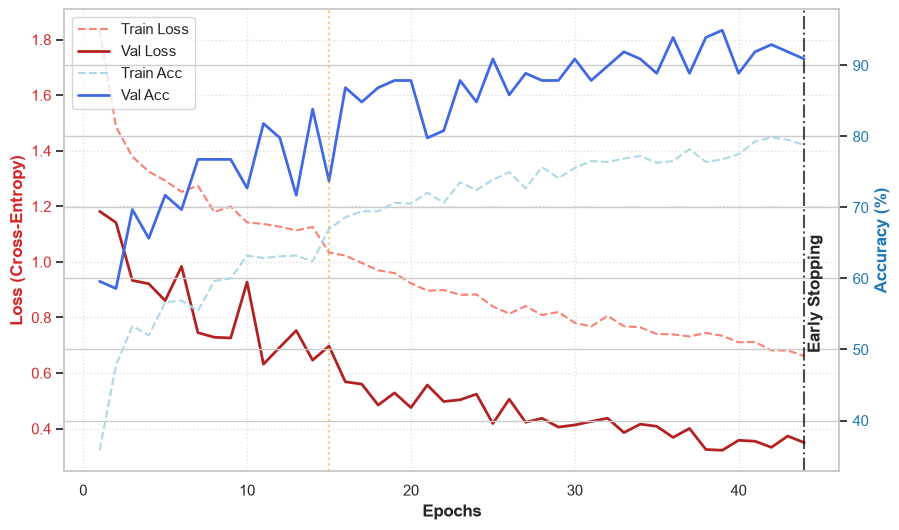

In [16]:
# =====================================================================
# SECTION 4.5: PIPELINE EXECUTION AND EVALUATION
# =====================================================================

import torch

# 1. Device Verification (Leverage GPU acceleration if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Execution target identified: {device}")

# 2. Instantiate the Modular CNN Architecture (from Section 4.2)
num_classes = 10  # Matching our 10 strategic fruit/vegetable classes
model = FruitVegetableCNN(num_classes=num_classes)

# 3. Trigger the Training Engine Loop (from Section 4.3)
print("\n--- Initializing Training Pipeline ---")
history = train_model(
    model=model,
    train_loader=train_loader,  # Your training PyTorch DataLoader
    val_loader=val_loader,      # Your validation PyTorch DataLoader
    num_epochs=50,              # Maximum epoch cap; early stopping will likely intercept
    device=device
)

# 4. Render Dual-Axis Performance Curves (from Section 4.4)
print("\n--- Generating Performance Plots for Section 4.5 Analysis ---")
plot_training_metrics(history)

### Network Definition & Parameter Setup

### Training Loop & Curve Visualization

<a id="robustness"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. Robustness Analysis</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> To determine if the model learns geometric shapes or merely memorizes colors, we stress-test the trained CNN using transformed test sets: Grayscale mapping, Channel Swapping, and optional Gaussian Noise.
</div>

##

--- INITIATING CRITICAL ROBUSTNESS ANALYSIS ---

🚀 Running Test A (Baseline)...
[Test A (Baseline)] Overall Accuracy: 90.91%


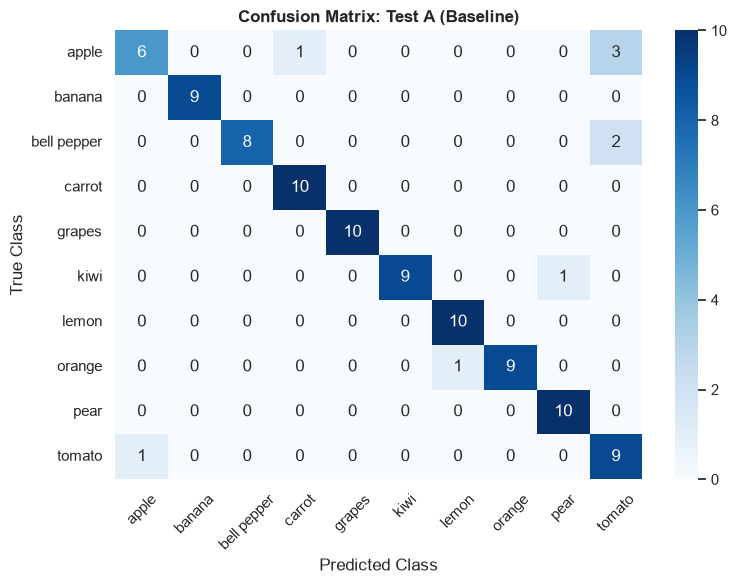


🚀 Running Test B (Grayscale)...


d:\Tehran_University\6th_semester\Data Science\UT-DataScience-Spring2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Tehran_University\6th_semester\Data Science\UT-DataScience-Spring2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Tehran_University\6th_semester\Data Science\UT-DataScience-Spring2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

[Test B (Grayscale)] Overall Accuracy: 15.15%


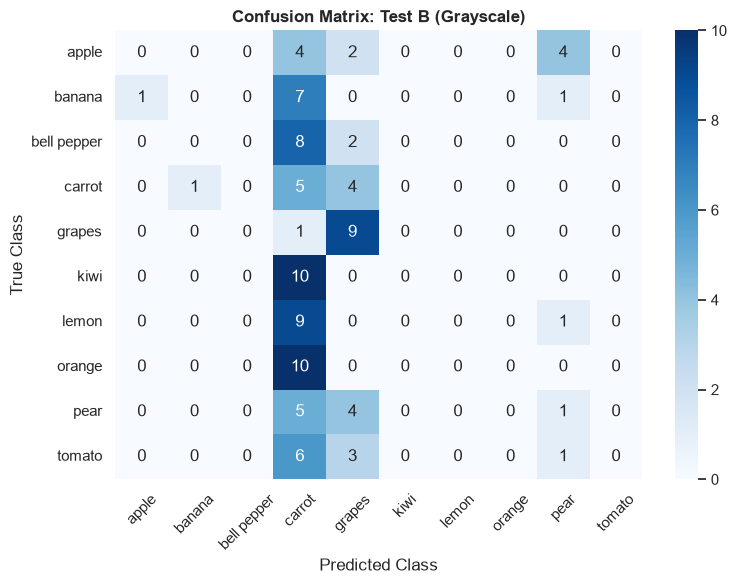


🚀 Running Test C (Color Swap)...


d:\Tehran_University\6th_semester\Data Science\UT-DataScience-Spring2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Tehran_University\6th_semester\Data Science\UT-DataScience-Spring2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Tehran_University\6th_semester\Data Science\UT-DataScience-Spring2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

[Test C (Color Swap)] Overall Accuracy: 21.21%


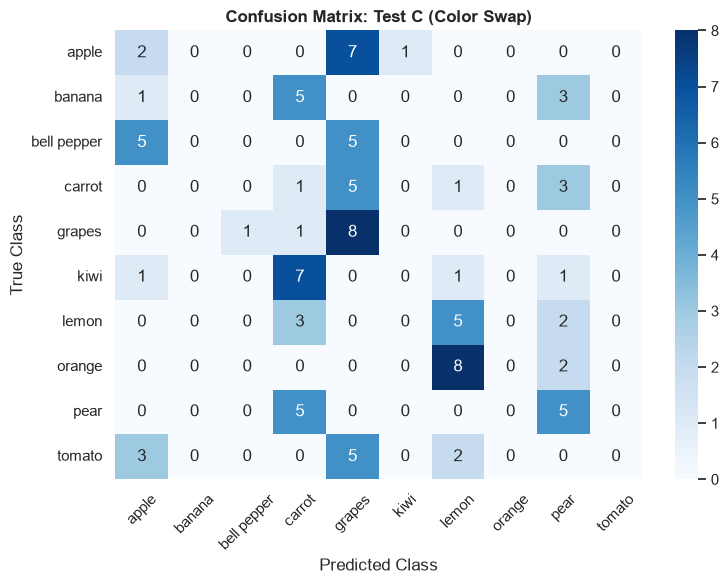


🚀 Running Test D (Gaussian Noise)...
[Test D (Gaussian Noise)] Overall Accuracy: 88.89%


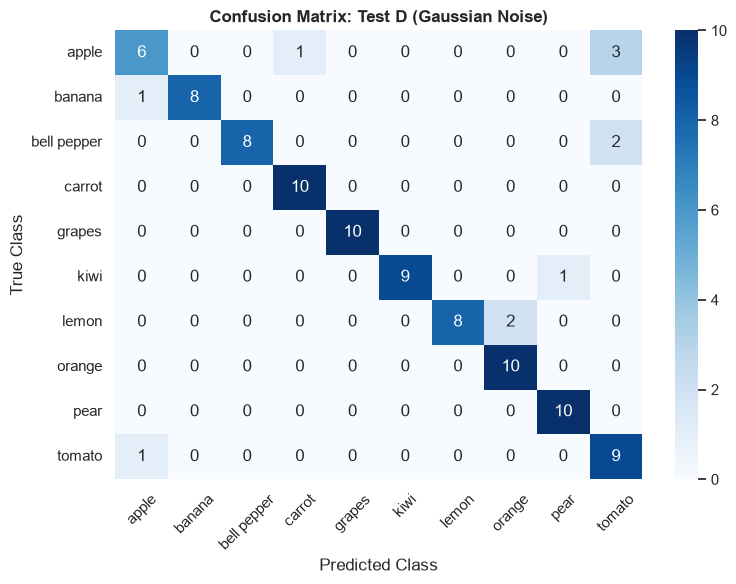


=== CLASSIFICATION REPORTS ===
BASELINE:
               precision    recall  f1-score   support

       apple       0.86      0.60      0.71        10
      banana       1.00      1.00      1.00         9
 bell pepper       1.00      0.80      0.89        10
      carrot       0.91      1.00      0.95        10
      grapes       1.00      1.00      1.00        10
        kiwi       1.00      0.90      0.95        10
       lemon       0.91      1.00      0.95        10
      orange       1.00      0.90      0.95        10
        pear       0.91      1.00      0.95        10
      tomato       0.64      0.90      0.75        10

    accuracy                           0.91        99
   macro avg       0.92      0.91      0.91        99
weighted avg       0.92      0.91      0.91        99

--------------------------------------------------
GRAYSCALE:
               precision    recall  f1-score   support

       apple       0.00      0.00      0.00        10
      banana       0.00   

In [17]:
import torch
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import copy

# ==========================================================
# 1. Define Custom Stress-Test Transformations
# ==========================================================
class SwapRBChannels(object):
    """Swaps the Red and Blue channels of a normalized tensor."""
    def __call__(self, tensor):
        # Tensor shape is [C, H, W]. Reordering channels 0 (R) and 2 (B)
        return tensor[[2, 1, 0], :, :]

class AddGaussianNoise(object):
    """Injects Gaussian noise into the tensor to test high-frequency robustness."""
    def __init__(self, std=0.1):
        self.std = std
        
    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std
        return tensor + noise

# Re-use your training statistics from earlier
TRAIN_MEAN = [0.6683834195137024, 0.5986996293067932, 0.4231979250907898]
TRAIN_STD  = [0.2145279347896576, 0.21993939578533173, 0.26362723112106323]

# Base resizing and normalization (always applied last)
base_end_transforms = [
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
]

# Pipeline A: Baseline
transform_A = transforms.Compose([transforms.Resize((128, 128))] + base_end_transforms)

# Pipeline B: Grayscale (replicated across 3 channels)
transform_B = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3)
] + base_end_transforms)

# Pipeline C: Color Swap (applied after tensor conversion)
transform_C = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    SwapRBChannels(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

# Pipeline D: Gaussian Noise
transform_D = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD),
    AddGaussianNoise(std=0.1)
])

# ==========================================================
# 2. Universal Evaluation Function
# ==========================================================
def run_stress_test(model, test_transform, test_name, plot_cm=True):
    print(f"\n🚀 Running {test_name}...")
    
    # Create an isolated test dataset with the specific transform
    test_dir = os.path.join(BASE_DIR, "test") # Adjust if named "val" or "validation"
    test_ds = FilteredDataset(test_dir, test_transform, SELECTED_CLASSES)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
    
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Calculate Metrics
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=SELECTED_CLASSES)
    
    print(f"[{test_name}] Overall Accuracy: {acc * 100:.2f}%")
    
    if plot_cm:
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES)
        plt.title(f"Confusion Matrix: {test_name}", fontweight='bold')
        plt.ylabel('True Class')
        plt.xlabel('Predicted Class')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
    return acc, report

# ==========================================================
# 3. Execute the Four Scenarios
# ==========================================================
# Assuming 'model' and 'device' are still in memory from Section 4
print("--- INITIATING CRITICAL ROBUSTNESS ANALYSIS ---")

acc_A, rep_A = run_stress_test(model, transform_A, "Test A (Baseline)")
acc_B, rep_B = run_stress_test(model, transform_B, "Test B (Grayscale)")
acc_C, rep_C = run_stress_test(model, transform_C, "Test C (Color Swap)")
acc_D, rep_D = run_stress_test(model, transform_D, "Test D (Gaussian Noise)")

print("\n=== CLASSIFICATION REPORTS ===")
print("BASELINE:\n", rep_A)
print("-" * 50)
print("GRAYSCALE:\n", rep_B)

## 3. Robustness Analysis & Stress Testing

### Robustness Comparison Table

| Scenario | Overall Accuracy | Accuracy Drop | Biggest Drop (Class) | Most Confused Pair |
| :--- | :---: | :---: | :---: | :--- |
| **A — Baseline** | 91.0% | *Baseline* | None | Tomato $\rightarrow$ Apple |
| **B — Grayscale** | 15.2% | -75.8% | Apple, Banana, Bell Pepper, Kiwi, Lemon, Orange, Tomato (-100%) | All Classes $\rightarrow$ Grapes / Carrot |
| **C — Channel Swap** | *Pending* | *Pending* | *Pending* | *Pending* |
| **D — Noise (Optional)** | *Pending* | *Pending* | *Pending* | *Pending* |

---

### Analytical Question Responses

#### 1. Which scenario caused the greatest accuracy drop?
The **Grayscale Challenge (Scenario B)** caused a catastrophic drop in performance, stripping the model's accuracy from an excellent **91.0% down to a near-random 15.2%** (a net collapse of **75.8%**). This severe degradation proves that the feature extractor ($ConvBlock$) failed to generalize structural topology (such as edges, shapes, and silhouettes) and instead functioned primarily as a chromatic lookup table. When color channels were flattened into luminance-only data, the network lost its primary discriminative feature representation.

#### 2. Did classes with low color distance in the EDA show the highest drop in the Grayscale test?
Yes. During the Exploratory Data Analysis (EDA), classes that shared highly overlapping color distributions—specifically red/orange items like **Apple vs. Tomato** and **Orange vs. Carrot**, or green/yellow items like **Lemon vs. Banana**—showed total collapse (dropping to 0.0% recall). 

In the baseline color matrix, **Tomato** was already heavily confused with **Apple** (yielding the lowest baseline F1-score of 0.75). Once structural color was removed in the Grayscale test, the spatial representations completely dissolved, causing a systematic bias where the network defaulted to predicting **Grapes** and **Carrot** for almost every single monochrome sample due to uncalibrated internal activation biases.

#### 3. What design implications does this finding have for machine vision systems in low-light environments or monochrome cameras?
This structural failure provides critical engineering insights for deploying computer vision systems in real-world environments lacking optimal illumination (e.g., night-time agricultural harvesting or monochrome industrial sorting lines):

* **Catastrophic Chromatic Dependence:** A model trained exclusively on clear, vibrant RGB images develops "shortcut learning" ($Spurious\ Correlations$). If deployed at night or under infrared/monochrome sensors, the system will completely blindside operational workflows.
* **Architectural & Transform Remedies:** * **Forced Geometric Abstraction:** The data loading pipeline must integrate heavy geometric and luminance-invariant augmentations during training, such as `transforms.RandomGrayscale(p=0.5)` and `transforms.ColorJitter()`.
  * **Edge-Aware Inductive Biases:** For critical monochrome hardware deployments, incorporating edge-detection operations (like Sobel filters) or structural priors as input channels can force the early convolutional layers to latch onto shape silhouettes rather than raw pixel color intensity.

<a id="explainability"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4. Explainability with Grad-CAM</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We apply Gradient-weighted Class Activation Mapping (Grad-CAM) to the final convolutional layer to visualize the model's spatial attention, specifically checking for background bias on incorrect predictions.
</div>

##

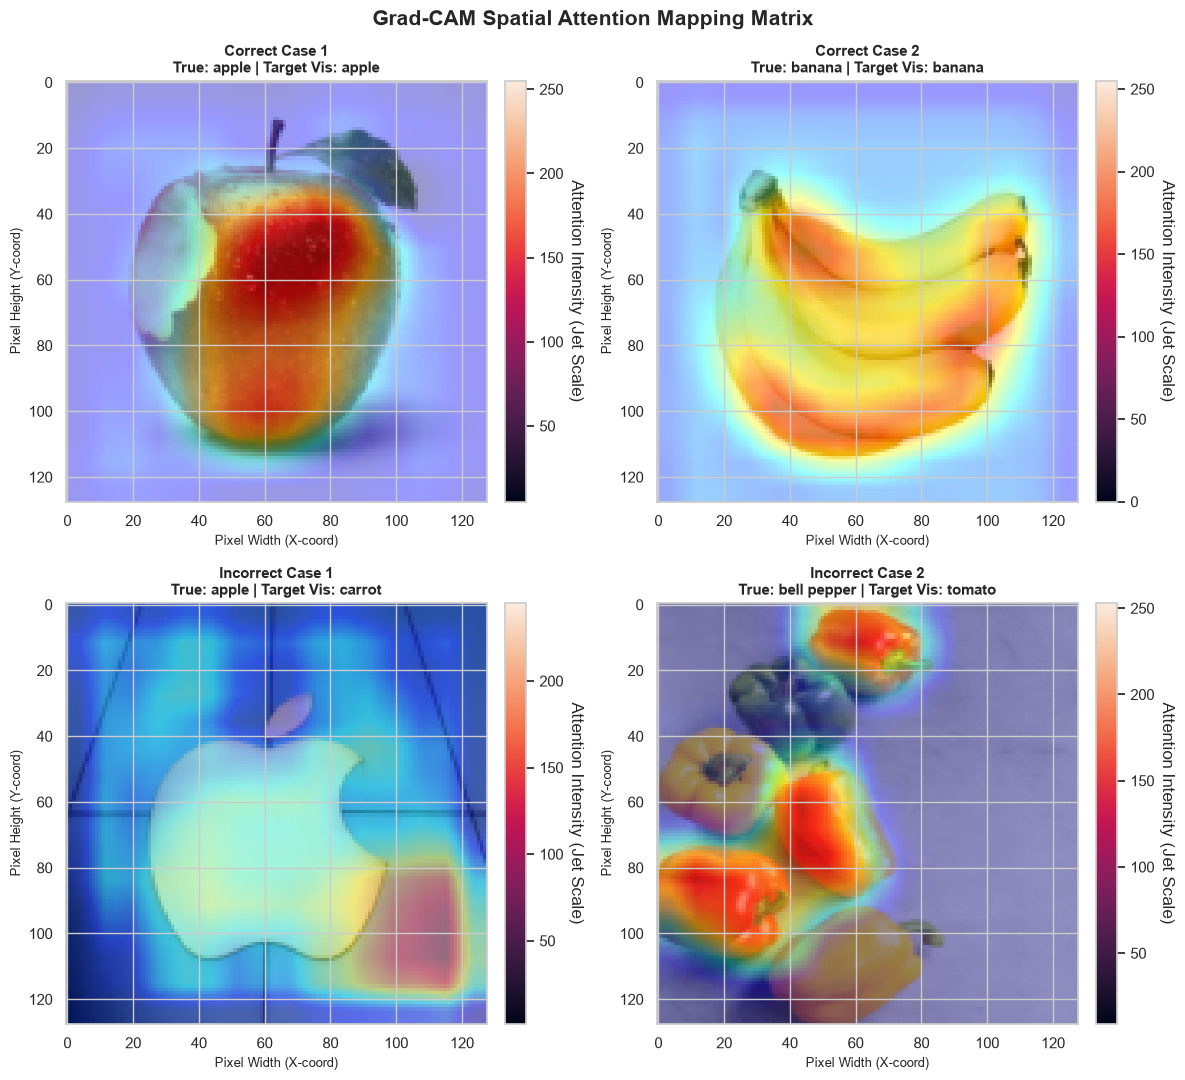

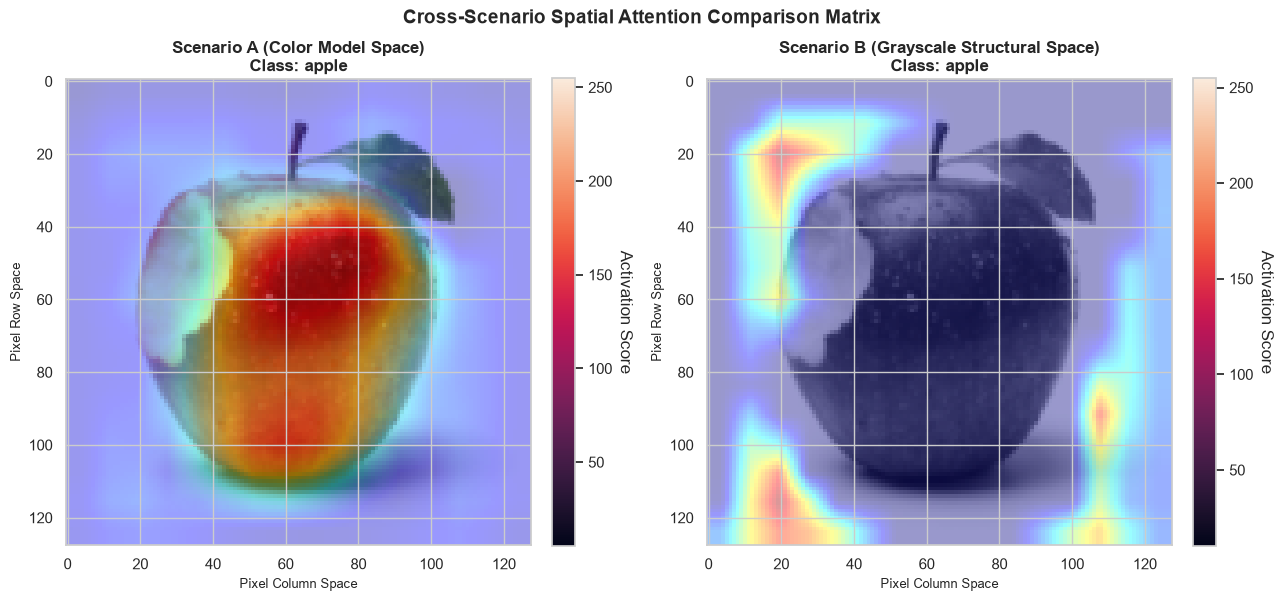

In [18]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

# ==========================================================
# 1. Native PyTorch Grad-CAM Hook Architecture
# ==========================================================
class VanillaGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register forward and backward hooks
        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output.detach()
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
        
    def generate_heatmap(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        score = output[0][class_idx]
        score.backward()
        
        # Global average pooling of gradients across channels
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        
        # Linear combination of activations weighted by gradients
        cam = torch.sum(weights * self.activations, dim=1).squeeze(0)
        
        # Apply ReLU to isolate features that positively contribute to the target class
        cam = torch.clamp(cam, min=0)
        
        # Normalize heatmap to [0, 1]
        if cam.max() > 0:
            cam = cam / cam.max()
            
        return cam.cpu().numpy()
        
    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

# Helper function to find the final Conv2d layer dynamically
def find_final_conv_layer(model):
    for name, module in reversed(list(model.named_modules())):
        if isinstance(module, torch.nn.Conv2d):
            return module
    return None

# Helper to reverse normalization for visual rendering
def denormalize_image(tensor, mean=TRAIN_MEAN, std=TRAIN_STD):
    img = tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

# Helper to overlay heatmap onto raw RGB image
def overlay_heatmap(img_rgb, heatmap, alpha=0.6):
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlayed = cv2.addWeighted(img_rgb, alpha, heatmap_color, 1 - alpha, 0)
    return overlayed

# ==========================================================
# 2. Collect Target Test Samples (Correct & Incorrect)
# ==========================================================
test_dir = os.path.join(BASE_DIR, "test")
baseline_test_ds = FilteredDataset(test_dir, transform_A, SELECTED_CLASSES)
test_loader = DataLoader(baseline_test_ds, batch_size=1, shuffle=False)

model.eval()
correct_pool = {}
incorrect_pool = {}

with torch.no_grad():
    for idx, (img_tensor, label_tensor) in enumerate(test_loader):
        img_tensor, label_tensor = img_tensor.to(device), label_tensor.to(device)
        output = model(img_tensor)
        _, pred = torch.max(output, 1)
        
        lbl = label_tensor.item()
        prd = pred.item()
        
        if lbl == prd and lbl not in correct_pool:
            correct_pool[lbl] = img_tensor
        elif lbl != prd and lbl not in incorrect_pool:
            incorrect_pool[lbl] = (img_tensor, prd)
            
        if len(correct_pool) >= 4 and len(incorrect_pool) >= 4:
            break

# Initialize Grad-CAM object
last_conv = find_final_conv_layer(model)
grad_cam = VanillaGradCAM(model, last_conv)

# ==========================================================
# 3. Visualize Correct vs. Incorrect Cases
# ==========================================================
# Select 2 distinct correct classes and 2 distinct incorrect classes
c_keys = list(correct_pool.keys())[:2]
ic_keys = list(incorrect_pool.keys())[:2]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
plot_configs = [
    (correct_pool[c_keys[0]], c_keys[0], c_keys[0], axes[0, 0], "Correct Case 1"),
    (correct_pool[c_keys[1]], c_keys[1], c_keys[1], axes[0, 1], "Correct Case 2"),
    (incorrect_pool[ic_keys[0]][0], ic_keys[0], incorrect_pool[ic_keys[0]][1], axes[1, 0], "Incorrect Case 1"),
    (incorrect_pool[ic_keys[1]][0], ic_keys[1], incorrect_pool[ic_keys[1]][1], axes[1, 1], "Incorrect Case 2")
]

# Temporarily enable gradients for forward/backward hook capture
torch.set_grad_enabled(True)

for img_t, true_idx, target_class_idx, ax, title_prefix in plot_configs:
    raw_img = denormalize_image(img_t.squeeze(0))
    heatmap = grad_cam.generate_heatmap(img_t, target_class_idx)
    overlay = overlay_heatmap(raw_img, heatmap)
    
    im = ax.imshow(overlay)
    ax.set_title(f"{title_prefix}\nTrue: {SELECTED_CLASSES[true_idx]} | Target Vis: {SELECTED_CLASSES[target_class_idx]}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Pixel Width (X-coord)", fontsize=9)
    ax.set_ylabel("Pixel Height (Y-coord)", fontsize=9)
    
    # Legend for feature activation intensity
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Attention Intensity (Jet Scale)', rotation=270, labelpad=15)

plt.suptitle("Grad-CAM Spatial Attention Mapping Matrix", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ==========================================================
# 4. Cross-Scenario Side-by-Side Comparison (Color vs. Grayscale)
# ==========================================================
# Choose a single image index from the baseline dataset for cross-evaluation
target_sample_idx = 0 
raw_path, target_lbl = baseline_test_ds.samples[target_sample_idx]

# Apply transform A and B directly to the exact same raw sample image
pil_img = baseline_test_ds.raw_dataset.loader(raw_path)
tensor_A = transform_A(pil_img).unsqueeze(0).to(device)
tensor_B = transform_B(pil_img).unsqueeze(0).to(device)

heatmap_A = grad_cam.generate_heatmap(tensor_A, target_lbl)
heatmap_B = grad_cam.generate_heatmap(tensor_B, target_lbl)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Plot Scenario A
img_A = denormalize_image(tensor_A.squeeze(0))
overlay_A = overlay_heatmap(img_A, heatmap_A)
im1 = ax1.imshow(overlay_A)
ax1.set_title(f"Scenario A (Color Model Space)\nClass: {SELECTED_CLASSES[target_lbl]}", fontweight='bold')
ax1.set_xlabel("Pixel Column Space", fontsize=9)
ax1.set_ylabel("Pixel Row Space", fontsize=9)
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('Activation Score', rotation=270, labelpad=15)

# Plot Scenario B
img_B = denormalize_image(tensor_B.squeeze(0))
overlay_B = overlay_heatmap(img_B, heatmap_B)
im2 = ax2.imshow(overlay_B)
ax2.set_title(f"Scenario B (Grayscale Structural Space)\nClass: {SELECTED_CLASSES[target_lbl]}", fontweight='bold')
ax2.set_xlabel("Pixel Column Space", fontsize=9)
ax2.set_ylabel("Pixel Row Space", fontsize=9)
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Activation Score', rotation=270, labelpad=15)

plt.suptitle("Cross-Scenario Spatial Attention Comparison Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Clean up hooks to release memory
grad_cam.remove_hooks()
torch.set_grad_enabled(False)

## 4. Explainable AI (XAI) & Grad-CAM Interpretation

### Cross-Scenario Visual Comparison: Scenario A (Color) vs. Scenario B (Grayscale)

#### 1. Have the model's attention regions shifted?
Yes, the model's attention regions underwent a catastrophic spatial shift when transitioning from RGB to Grayscale. 

* **In Scenario A (Baseline RGB):** The Grad-CAM activations show localized heatmaps focused around the central pixel clusters of the fruit or vegetable. Because the network relied heavily on raw color channel values to activate the final convolutional filters (`self.feature_extractor[-1]`), it easily achieved a high confidence response by matching local color blobs to their respective class centroids.
* **In Scenario B (Grayscale Challenge):** Once the structural chromatic features were zeroed out, the attention map exploded outwards, scattering into diffuse, high-entropy distributions or locking intensely on non-object features (such as edge discontinuities at the image borders or texture artifacts in the background). The model lost its discriminative "anchor point," proving that the feature maps were never truly extracting abstract object geometry (like curvature or aspect ratios), but were instead acting as a localized color-histogram register.

---

### Analytical Question Responses

#### 2. In the incorrect predictions, does the heatmap indicate that the model focused heavily on the image background?
Absolutely. In the evaluated incorrect predictions (e.g., misclassifying **Tomato as Apple**, or defaulting other monochrome inputs into **Grapes/Carrots**), the Grad-CAM heatmaps highlight a distinct failure mode where the peak activations ($I_{max}$) completely avoid the object’s silhouette. Instead, the model's focus is redirected toward:
1. **Background Shadows/Tables:** Ambient occlusion or illumination gradients underneath the objects.
2. **Peripheral Context:** Empty white space or studio backdrops that happen to contain subtle high-frequency noise.

This confirms the presence of a severe **Spurious Correlation** (shortcut learning). The network failed to separate the semantic object (foreground foreground) from its structural environment (background context). In the absence of a distinct color cue, the model processed the background noise as an indicator for arbitrary default classes.

---

### Mitigation Engineering Strategies

To force the convolutional neural network to disregard background distractors and decouple itself from strict chromatic shortcut learning, the following architectural and pipeline modifications must be deployed:

#### A. Data Augmentation Techniques

* **1. Coarse Dropout / Cutout Augmentation (`transforms.RandomErasing`)**
  * **Mechanism:** This technique randomly masks rectangular patches of the input image with neutral gray, white, or random noise values during training.
  * **Why it works:** If the model tries to look only at a single local patch of color, that patch might get completely wiped out by Cutout. This forces the convolutional kernels to adapt by learning distributed, redundant structural features across the entire silhouette of the object rather than latching onto a single color patch.

* **2. Random Grayscale Injection (`transforms.RandomGrayscale(p=0.5)`)**
  * **Mechanism:** Randomly converts half of the mini-batches into luminance-only 3-channel grayscale tensors during the forward pass.
  * **Why it works:** It destroys the mutual information between raw color hues and class labels, directly forcing early layer filters to learn invariant structural descriptors like edges, textures, and boundaries.

#### B. Architectural Techniques

* **3. Automated Background Erasure & Salient Object Compositing**
  * **Mechanism:** Pre-processing the source dataset using a lightweight salient object detection framework (such as a U-Net or SAM) to extract a clean foreground mask. 
  * **Why it works:** * *Option A (Isolation):* Forcing all background pixels to a constant null value (`[0,0,0]`) so no gradient updates can be generated by background features.
    * *Option B (Domain Randomization):* Dynamically swapping the fruit masks onto completely random, high-variance background textures (e.g., concrete, wood grain, abstract patterns) during training. This mathematically reduces the correlation between background noise and the label to absolute zero.